# Retail Sales & Customer Analytics

## 1. Business Context

This project analyzes retail sales and customer data to understand purchasing behavior, sales performance, product-category contribution, and channel/store performance.

The business operates across multiple store and sales channels and serves customers across different locations. Management wants to use historical transaction data to understand what is driving revenue, which product categories and sub-categories perform best, how customers contribute to sales, and where opportunities exist to improve business performance.

The analysis integrates three data sources:

- Customer data
- Transaction data
- Product category and sub-category information

By combining these datasets, the project creates a consolidated view of customer transactions and product performance. The analysis is designed to support data-driven decisions related to sales strategy, customer retention, product planning, inventory focus, channel performance, and return management.

---

## 2. Business Problem

The business has a large volume of historical retail transaction data but needs a structured analytical approach to answer key business questions:

- Which product categories and sub-categories generate the most transaction value?
- Which store or sales channels perform best?
- What are the purchasing patterns of different customer segments?
- How does sales performance change over time?
- Which customers contribute significantly to overall transaction value?
- What is the impact of returns or negative-quantity transactions?
- Where are the major opportunities for improving sales and customer value?

---

## 3. Business Objectives

The primary objectives of this analysis are to:

1. Assess the quality and structure of the available retail data.
2. Integrate customer, transaction, and product information into a single analytical dataset.
3. Analyze overall sales and transaction performance.
4. Identify high-performing product categories and sub-categories.
5. Evaluate store/channel performance.
6. Understand customer purchasing behavior and customer value.
7. Analyze sales trends across time.
8. Examine return/negative-quantity transactions.
9. Identify meaningful business patterns and opportunities.
10. Translate analytical findings into actionable business recommendations.

---

## 4. Key Business Questions

The analysis will focus on answering the following questions:

### Sales Performance
- What is the overall transaction value?
- What is the average transaction value?
- How does sales performance vary over time?
- Which channels contribute most to transaction value?

### Customer Analytics
- How many unique customers are served?
- Which customer groups contribute most to transaction value?
- Who are the highest-value customers?
- What patterns can be observed in customer purchasing behavior?

### Product Analytics
- Which product categories perform best?
- Which sub-categories contribute most to transaction value?
- Which categories may require additional attention?

### Channel Analytics
- Which store/channel generates the highest transaction value?
- How does performance differ across channels?

### Returns Analysis
- How significant are negative-quantity transactions?
- Which categories and channels have higher return activity?

---

## 5. Analytical Approach

The project follows an end-to-end analytics workflow:

**Data Collection → Data Understanding → Data Quality Assessment → Data Cleaning → Data Integration → Feature Engineering → Exploratory Data Analysis → Business KPI Analysis → Visualization → Insights → Recommendations**

The final objective is not only to describe the data but to convert the analysis into business-relevant insights that can support management decision-making.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [4]:
customer = pd.read_csv(r"C:\Users\Anshi Tanwar\OneDrive\Desktop\Retail_Sales_Customer_Analytics\Customer.csv")

transactions = pd.read_csv(r"C:\Users\Anshi Tanwar\OneDrive\Desktop\Retail_Sales_Customer_Analytics\Transactions.csv")

product_info = pd.read_csv(r"C:\Users\Anshi Tanwar\OneDrive\Desktop\Retail_Sales_Customer_Analytics\prod_cat_info.csv")

In [5]:
print("Customer dataset:", customer.shape)
print("Transactions dataset:", transactions.shape)
print("Product information dataset:", product_info.shape)

Customer dataset: (5647, 4)
Transactions dataset: (23053, 10)
Product information dataset: (23, 4)


In [6]:
customer.head()

,customer_Id,DOB,Gender,city_code
0,268408,02-01-1970,M,4.00
1,269696,07-01-1970,F,8.00
2,268159,08-01-1970,F,8.00
3,270181,10-01-1970,F,2.00
4,268073,11-01-1970,M,1.00


In [7]:
transactions.head()

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type
0,80712190438,270351,28-02-2014,1,1,-5,-772,405.30,"-4,265.30",e-Shop
1,29258453508,270384,27-02-2014,5,3,-5,-1497,785.92,"-8,270.92",e-Shop
2,51750724947,273420,24-02-2014,6,5,-2,-791,166.11,"-1,748.11",TeleShop
3,93274880719,271509,24-02-2014,11,6,-3,-1363,429.35,"-4,518.35",e-Shop
4,51750724947,273420,23-02-2014,6,5,-2,-791,166.11,"-1,748.11",TeleShop


In [8]:
product_info.head()

,prod_cat_code,prod_cat,prod_sub_cat_code,prod_subcat
0,1,Clothing,4,Mens
1,1,Clothing,1,Women
2,1,Clothing,3,Kids
3,2,Footwear,1,Mens
4,2,Footwear,3,Women


In [9]:
print("Customer columns:")
print(customer.columns.tolist())

print("\nTransaction columns:")
print(transactions.columns.tolist())

print("\nProduct information columns:")
print(product_info.columns.tolist())

Customer columns:
['customer_Id', 'DOB', 'Gender', 'city_code']

Transaction columns:
['transaction_id', 'cust_id', 'tran_date', 'prod_subcat_code', 'prod_cat_code', 'Qty', 'Rate', 'Tax', 'total_amt', 'Store_type']

Product information columns:
['prod_cat_code', 'prod_cat', 'prod_sub_cat_code', 'prod_subcat']


## 6. Data Understanding

Before performing any analysis, the three datasets are examined to understand their structure, data types, completeness, and quality. This step helps identify potential issues that may affect the accuracy of the analysis.

In [10]:
print("CUSTOMER DATASET")
customer.info()

print("\nTRANSACTIONS DATASET")
transactions.info()

print("\nPRODUCT INFORMATION DATASET")
product_info.info()

CUSTOMER DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5647 entries, 0 to 5646
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_Id  5647 non-null   int64  
 1   DOB          5647 non-null   object 
 2   Gender       5645 non-null   object 
 3   city_code    5645 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 176.6+ KB

TRANSACTIONS DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23053 entries, 0 to 23052
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    23053 non-null  int64  
 1   cust_id           23053 non-null  int64  
 2   tran_date         23053 non-null  object 
 3   prod_subcat_code  23053 non-null  int64  
 4   prod_cat_code     23053 non-null  int64  
 5   Qty               23053 non-null  int64  
 6   Rate              23053 non-null  int64  
 7   Ta

### 6.1 Missing Value Analysis

Missing values are examined across all three datasets to determine whether data cleaning or treatment is required before analysis.

In [11]:
print("Customer Dataset - Missing Values")
display(customer.isnull().sum())

print("\nTransactions Dataset - Missing Values")
display(transactions.isnull().sum())

print("\nProduct Information Dataset - Missing Values")
display(product_info.isnull().sum())

Customer Dataset - Missing Values


customer_Id    0
DOB            0
Gender         2
city_code      2
dtype: int64


Transactions Dataset - Missing Values


transaction_id      0
cust_id             0
tran_date           0
prod_subcat_code    0
prod_cat_code       0
Qty                 0
Rate                0
Tax                 0
total_amt           0
Store_type          0
dtype: int64


Product Information Dataset - Missing Values


prod_cat_code        0
prod_cat             0
prod_sub_cat_code    0
prod_subcat          0
dtype: int64

In [12]:
def missing_value_summary(df):
    missing_count = df.isnull().sum()
    missing_percentage = (missing_count / len(df)) * 100
    
    summary = pd.DataFrame({
        "Missing Values": missing_count,
        "Missing Percentage": missing_percentage
    })
    
    return summary.sort_values(
        "Missing Percentage", 
        ascending=False
    )

print("Customer Dataset")
display(missing_value_summary(customer))

print("Transactions Dataset")
display(missing_value_summary(transactions))

print("Product Information Dataset")
display(missing_value_summary(product_info))

Customer Dataset


,Missing Values,Missing Percentage
Gender,2,0.04
city_code,2,0.04
customer_Id,0,0.00
DOB,0,0.00


Transactions Dataset


,Missing Values,Missing Percentage
transaction_id,0,0.00
cust_id,0,0.00
tran_date,0,0.00
prod_subcat_code,0,0.00
prod_cat_code,0,0.00
Qty,0,0.00
Rate,0,0.00
Tax,0,0.00
total_amt,0,0.00
Store_type,0,0.00


Product Information Dataset


,Missing Values,Missing Percentage
prod_cat_code,0,0.00
prod_cat,0,0.00
prod_sub_cat_code,0,0.00
prod_subcat,0,0.00


### 6.2 Duplicate Record Analysis

Duplicate records can lead to inflated transaction counts and incorrect sales calculations. Therefore, duplicate records are examined before performing the analysis.

In [13]:
print("Customer duplicate rows:", customer.duplicated().sum())

print("Transactions duplicate rows:", transactions.duplicated().sum())

print("Product information duplicate rows:", product_info.duplicated().sum())

Customer duplicate rows: 0
Transactions duplicate rows: 13
Product information duplicate rows: 0


In [14]:
print(
    "Duplicate Customer IDs:",
    customer["customer_Id"].duplicated().sum()
)

Duplicate Customer IDs: 0


In [15]:
print(
    "Duplicate Transaction IDs:",
    transactions["transaction_id"].duplicated().sum()
)

Duplicate Transaction IDs: 2175


In [16]:
print(
    "Duplicate Product Category/Sub-category combinations:",
    product_info[
        ["prod_cat_code", "prod_sub_cat_code"]
    ].duplicated().sum()
)

Duplicate Product Category/Sub-category combinations: 0


## 7. Data Cleaning

### 7.1 Duplicate Record Handling

Duplicate records were investigated across the customer, transaction, and product datasets.

Exact duplicate rows are removed where they represent repeated copies of the same record. Business-key duplicates such as repeated customer IDs or transaction IDs are investigated separately to distinguish genuine multiple records from data-quality issues.

In [17]:
print("Customer duplicate rows:", customer.duplicated().sum())
print("Transactions duplicate rows:", transactions.duplicated().sum())
print("Product information duplicate rows:", product_info.duplicated().sum())

Customer duplicate rows: 0
Transactions duplicate rows: 13
Product information duplicate rows: 0


In [18]:
customer = customer.drop_duplicates().copy()
transactions = transactions.drop_duplicates().copy()
product_info = product_info.drop_duplicates().copy()

print("Customer shape after duplicate removal:", customer.shape)
print("Transactions shape after duplicate removal:", transactions.shape)
print("Product information shape after duplicate removal:", product_info.shape)

Customer shape after duplicate removal: (5647, 4)
Transactions shape after duplicate removal: (23040, 10)
Product information shape after duplicate removal: (23, 4)


### 7.2 Date Standardization

The transaction date and customer date of birth fields are converted into datetime format to support accurate time-based analysis and customer-level calculations.

In [19]:
transactions["tran_date"] = pd.to_datetime(
    transactions["tran_date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

customer["DOB"] = pd.to_datetime(
    customer["DOB"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

In [20]:
print("Transaction date data type:", transactions["tran_date"].dtype)
print("Customer DOB data type:", customer["DOB"].dtype)

Transaction date data type: datetime64[ns]
Customer DOB data type: datetime64[ns]


### 7.3 Date Quality Validation

After standardizing the date fields, missing or invalid dates are checked to ensure that the datasets are suitable for time-based analysis.

In [21]:
print(
    "Missing/invalid transaction dates:",
    transactions["tran_date"].isna().sum()
)

print(
    "Missing/invalid customer DOB values:",
    customer["DOB"].isna().sum()
)

Missing/invalid transaction dates: 0
Missing/invalid customer DOB values: 0


In [22]:
print("Transaction date range:")
print("Start:", transactions["tran_date"].min())
print("End:", transactions["tran_date"].max())

Transaction date range:
Start: 2011-01-25 00:00:00
End: 2014-02-28 00:00:00


### 7.4 Numerical Data Validation

Numerical transaction fields are converted into appropriate numeric data types to ensure reliable calculations during the analysis.

In [23]:
numeric_columns = [
    "prod_subcat_code",
    "prod_cat_code",
    "Qty",
    "Rate",
    "Tax",
    "total_amt"
]

for col in numeric_columns:
    transactions[col] = pd.to_numeric(
        transactions[col],
        errors="coerce"
    )

In [24]:
transactions[numeric_columns].info()

<class 'pandas.core.frame.DataFrame'>
Index: 23040 entries, 0 to 23052
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   prod_subcat_code  23040 non-null  int64  
 1   prod_cat_code     23040 non-null  int64  
 2   Qty               23040 non-null  int64  
 3   Rate              23040 non-null  int64  
 4   Tax               23040 non-null  float64
 5   total_amt         23040 non-null  float64
dtypes: float64(2), int64(4)
memory usage: 1.2 MB


### 7.5 Negative Quantity Assessment

Negative quantities are retained because they may represent product returns or transaction reversals. These records are not removed as data errors and will be analyzed separately during the business analysis.

In [25]:
print(
    "Negative Qty records:",
    (transactions["Qty"] < 0).sum()
)

print(
    "Zero Qty records:",
    (transactions["Qty"] == 0).sum()
)

print(
    "Positive Qty records:",
    (transactions["Qty"] > 0).sum()
)

Negative Qty records: 2164
Zero Qty records: 0
Positive Qty records: 20876


# 8. Data Integration

The cleaned customer, transaction, and product datasets are integrated into a consolidated master dataset.

The transaction dataset serves as the central transactional dataset. Customer information is linked using `cust_id` from the transaction dataset and `customer_Id` from the customer dataset. Product information is then linked using the product category and sub-category codes.

## 8.1 Customer-Transaction Integration

Customer information is joined to the transaction dataset using the customer identifier. Multiple transaction records can belong to the same customer, so the relationship is validated as many transactions to one customer.

In [26]:
customer_final = transactions.merge(
    customer,
    left_on="cust_id",
    right_on="customer_Id",
    how="left",
    validate="many_to_one"
)

print("Customer-Transaction dataset shape:")
print(customer_final.shape)

display(customer_final.head())

Customer-Transaction dataset shape:
(23040, 14)


,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,customer_Id,DOB,Gender,city_code
0,80712190438,270351,2014-02-28,1,1,-5,-772,405.30,"-4,265.30",e-Shop,270351,1981-09-26,M,5.00
1,29258453508,270384,2014-02-27,5,3,-5,-1497,785.92,"-8,270.92",e-Shop,270384,1973-05-11,F,8.00
2,51750724947,273420,2014-02-24,6,5,-2,-791,166.11,"-1,748.11",TeleShop,273420,1992-07-27,M,8.00
3,93274880719,271509,2014-02-24,11,6,-3,-1363,429.35,"-4,518.35",e-Shop,271509,1981-06-08,M,3.00
4,51750724947,273420,2014-02-23,6,5,-2,-791,166.11,"-1,748.11",TeleShop,273420,1992-07-27,M,8.00


## 8.2 Customer Integration Validation

The customer merge is validated to determine whether transaction records have been successfully matched with customer demographic and location information.

In [27]:
print(
    "Transactions without matched customer DOB:",
    customer_final["DOB"].isna().sum()
)

print(
    "Transactions without matched Gender:",
    customer_final["Gender"].isna().sum()
)

print(
    "Transactions without matched city_code:",
    customer_final["city_code"].isna().sum()
)

Transactions without matched customer DOB: 0
Transactions without matched Gender: 9
Transactions without matched city_code: 8


## 8.3 Product Information Integration

Product category and sub-category descriptions are added to the consolidated dataset using the product category and sub-category codes.

The transaction dataset uses `prod_subcat_code`, whereas the product information dataset uses `prod_sub_cat_code`. The corresponding fields are explicitly mapped during integration.

In [28]:
customer_final = customer_final.merge(
    product_info,
    left_on=[
        "prod_cat_code",
        "prod_subcat_code"
    ],
    right_on=[
        "prod_cat_code",
        "prod_sub_cat_code"
    ],
    how="left",
    validate="many_to_one"
)

print("Master dataset shape:")
print(customer_final.shape)

display(customer_final.head())

Master dataset shape:
(23040, 17)


,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,customer_Id,DOB,Gender,city_code,prod_cat,prod_sub_cat_code,prod_subcat
0,80712190438,270351,2014-02-28,1,1,-5,-772,405.30,"-4,265.30",e-Shop,270351,1981-09-26,M,5.00,Clothing,1,Women
1,29258453508,270384,2014-02-27,5,3,-5,-1497,785.92,"-8,270.92",e-Shop,270384,1973-05-11,F,8.00,Electronics,5,Computers
2,51750724947,273420,2014-02-24,6,5,-2,-791,166.11,"-1,748.11",TeleShop,273420,1992-07-27,M,8.00,Books,6,DIY
3,93274880719,271509,2014-02-24,11,6,-3,-1363,429.35,"-4,518.35",e-Shop,271509,1981-06-08,M,3.00,Home and kitchen,11,Bath
4,51750724947,273420,2014-02-23,6,5,-2,-791,166.11,"-1,748.11",TeleShop,273420,1992-07-27,M,8.00,Books,6,DIY


## 8.4 Product Integration Validation

The product mapping is validated to ensure that transaction records have been successfully linked with their corresponding product category and sub-category information.

In [29]:
print(
    "Transactions without matched prod_cat:",
    customer_final["prod_cat"].isna().sum()
)

print(
    "Transactions without matched prod_subcat:",
    customer_final["prod_subcat"].isna().sum()
)

Transactions without matched prod_cat: 0
Transactions without matched prod_subcat: 0


In [30]:
customer_final.drop(
    columns=[
        "customer_Id",
        "prod_sub_cat_code"
    ],
    inplace=True
)

In [31]:
print(customer_final.columns.tolist())

['transaction_id', 'cust_id', 'tran_date', 'prod_subcat_code', 'prod_cat_code', 'Qty', 'Rate', 'Tax', 'total_amt', 'Store_type', 'DOB', 'Gender', 'city_code', 'prod_cat', 'prod_subcat']


# 9. Master Dataset Validation

The consolidated master dataset is validated after integration to ensure that transaction records have been preserved and that customer and product information has been successfully incorporated.

In [32]:
print("Master dataset shape:", customer_final.shape)

print(
    "Duplicate rows:",
    customer_final.duplicated().sum()
)

print("\nMissing values:")
display(customer_final.isna().sum())

Master dataset shape: (23040, 15)
Duplicate rows: 0

Missing values:


transaction_id      0
cust_id             0
tran_date           0
prod_subcat_code    0
prod_cat_code       0
Qty                 0
Rate                0
Tax                 0
total_amt           0
Store_type          0
DOB                 0
Gender              9
city_code           8
prod_cat            0
prod_subcat         0
dtype: int64

In [33]:
customer_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23040 entries, 0 to 23039
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    23040 non-null  int64         
 1   cust_id           23040 non-null  int64         
 2   tran_date         23040 non-null  datetime64[ns]
 3   prod_subcat_code  23040 non-null  int64         
 4   prod_cat_code     23040 non-null  int64         
 5   Qty               23040 non-null  int64         
 6   Rate              23040 non-null  int64         
 7   Tax               23040 non-null  float64       
 8   total_amt         23040 non-null  float64       
 9   Store_type        23040 non-null  object        
 10  DOB               23040 non-null  datetime64[ns]
 11  Gender            23031 non-null  object        
 12  city_code         23032 non-null  float64       
 13  prod_cat          23040 non-null  object        
 14  prod_subcat       2304

# 10. Feature Engineering

Additional analytical variables are created from the master dataset to support time-based, customer, sales, and return analysis.

In [34]:
  ####10.1 Date Features
customer_final["Year"] = customer_final["tran_date"].dt.year

customer_final["Month"] = customer_final["tran_date"].dt.month

customer_final["Month_Name"] = (
    customer_final["tran_date"].dt.month_name()
)

customer_final["Quarter"] = (
    customer_final["tran_date"].dt.quarter
)

### 10.2 Transaction Type

Transactions are classified into sales and returns based on the quantity field. Records with negative quantities are classified as returns, while non-negative quantities are treated as sales.

In [35]:
customer_final["Transaction_Type"] = np.where(
    customer_final["Qty"] < 0,
    "Return",
    "Sale"
)

In [36]:
customer_final["Transaction_Type"].value_counts()

Transaction_Type
Sale      20876
Return     2164
Name: count, dtype: int64

### 10.3 Customer Age

Customer age is estimated using the customer's date of birth and the transaction date. This enables analysis of transaction behavior across different customer age groups.

In [37]:
customer_final["Age"] = (
    (
        customer_final["tran_date"]
        - customer_final["DOB"]
    ).dt.days / 365.25
).round(0)

In [38]:
customer_final["Age"].describe()

count   23,040.00
mean        31.07
std          6.69
min         18.00
25%         25.00
50%         31.00
75%         37.00
max         44.00
Name: Age, dtype: float64

# 11. Overall Business Performance

Key performance indicators are calculated to establish an overall view of transaction value, transaction volume, customer reach, quantity, and return activity.

In [39]:
total_transaction_value = customer_final["total_amt"].sum()

total_quantity = customer_final["Qty"].sum()

total_transactions = (
    customer_final["transaction_id"].nunique()
)

unique_customers = (
    customer_final["cust_id"].nunique()
)

average_transaction_value = (
    customer_final["total_amt"].mean()
)

return_transactions = (
    customer_final["Transaction_Type"] == "Return"
).sum()

print("Total Transaction Value:", total_transaction_value)
print("Total Quantity:", total_quantity)
print("Total Unique Transactions:", total_transactions)
print("Unique Customers:", unique_customers)
print("Average Transaction Value:", average_transaction_value)
print("Return Transactions:", return_transactions)

Total Transaction Value: 48611294.809999995
Total Quantity: 56120
Total Unique Transactions: 20878
Unique Customers: 5506
Average Transaction Value: 2109.865226128472
Return Transactions: 2164


# 12. Sales Performance Analysis

Sales performance is analyzed across time to identify changes in transaction value, transaction volume, and customer activity.

In [40]:
yearly_sales = (
    customer_final
    .groupby("Year")
    .agg(
        Transaction_Value=("total_amt", "sum"),
        Transactions=("transaction_id", "nunique"),
        Customers=("cust_id", "nunique")
    )
    .reset_index()
)

display(yearly_sales)

,Year,Transaction_Value,Transactions,Customers
0,2011,"14,743,413.88",6325,3790
1,2012,"15,918,256.51",6826,3946
2,2013,"15,713,981.79",6784,3952
3,2014,"2,235,642.63",965,895


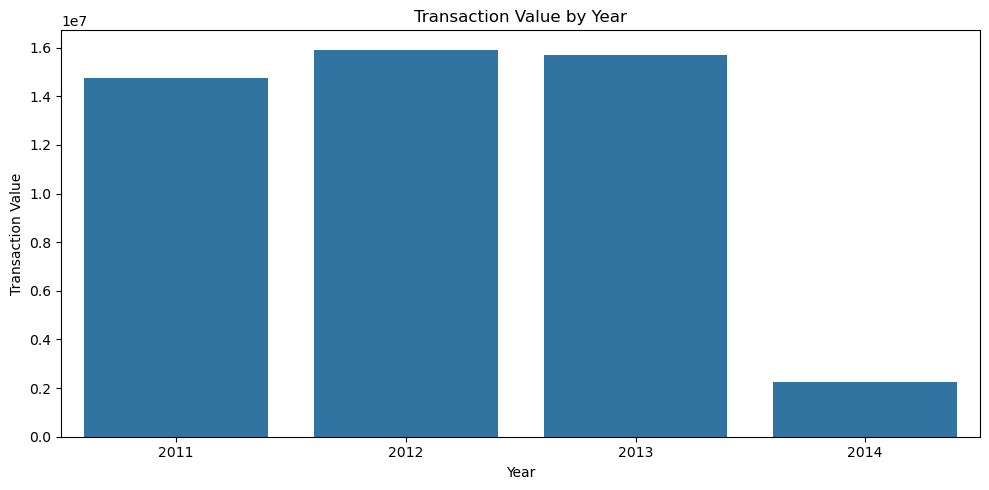

In [41]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=yearly_sales,
    x="Year",
    y="Transaction_Value"
)

plt.title("Transaction Value by Year")
plt.xlabel("Year")
plt.ylabel("Transaction Value")

plt.tight_layout()
plt.show()

In [42]:
monthly_sales = (
    customer_final
    .groupby(["Year", "Month"])
    .agg(
        Transaction_Value=("total_amt", "sum"),
        Transactions=("transaction_id", "nunique"),
        Customers=("cust_id", "nunique")
    )
    .reset_index()
)

monthly_sales.head()

,Year,Month,Transaction_Value,Transactions,Customers
0,2011,1,"337,307.88",136,135
1,2011,2,"1,087,283.53",507,485
2,2011,3,"1,376,537.18",591,566
3,2011,4,"1,379,838.92",567,536
4,2011,5,"1,174,157.53",543,514


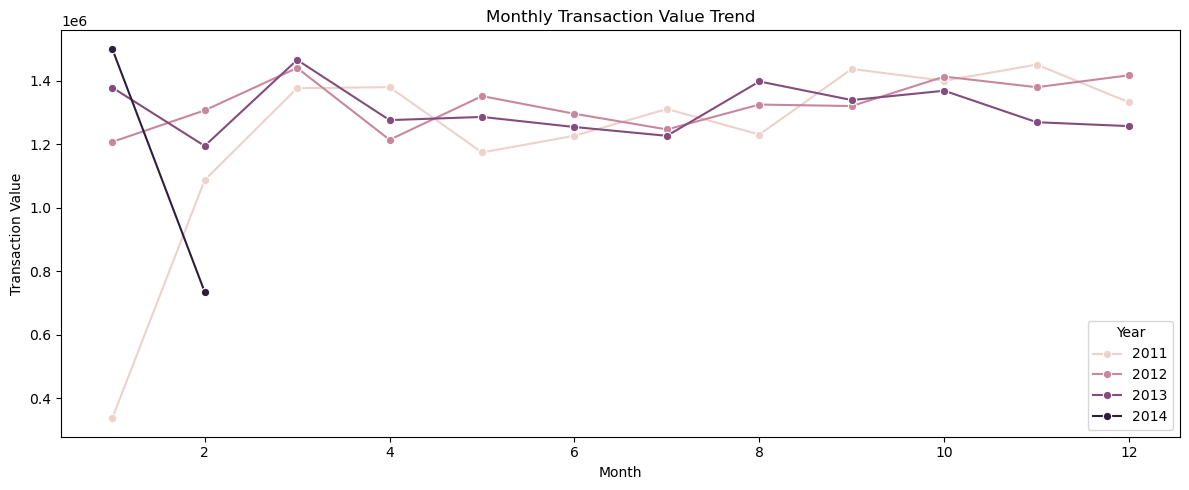

In [43]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_sales,
    x="Month",
    y="Transaction_Value",
    hue="Year",
    marker="o"
)

plt.title("Monthly Transaction Value Trend")
plt.xlabel("Month")
plt.ylabel("Transaction Value")

plt.tight_layout()
plt.show()

# 13. Product Performance Analysis

Product categories and sub-categories are analyzed using transaction value, quantity, transaction volume, and customer contribution to identify the strongest and weakest areas of product performance.

In [44]:
category_performance = (
    customer_final
    .groupby("prod_cat")
    .agg(
        Transaction_Value=("total_amt", "sum"),
        Quantity=("Qty", "sum"),
        Transactions=("transaction_id", "nunique"),
        Customers=("cust_id", "nunique")
    )
    .sort_values(
        "Transaction_Value",
        ascending=False
    )
    .reset_index()
)

display(category_performance)

,prod_cat,Transaction_Value,Quantity,Transactions,Customers
0,Books,"12,832,592.63",14679,5486,3480
1,Electronics,"10,730,705.83",12318,4486,3087
2,Home and kitchen,"8,444,612.21",9954,3733,2720
3,Clothing,"6,251,137.49",7174,2676,2121
4,Footwear,"6,225,904.82",7285,2708,2144
5,Bags,"4,126,341.83",4710,1789,1524


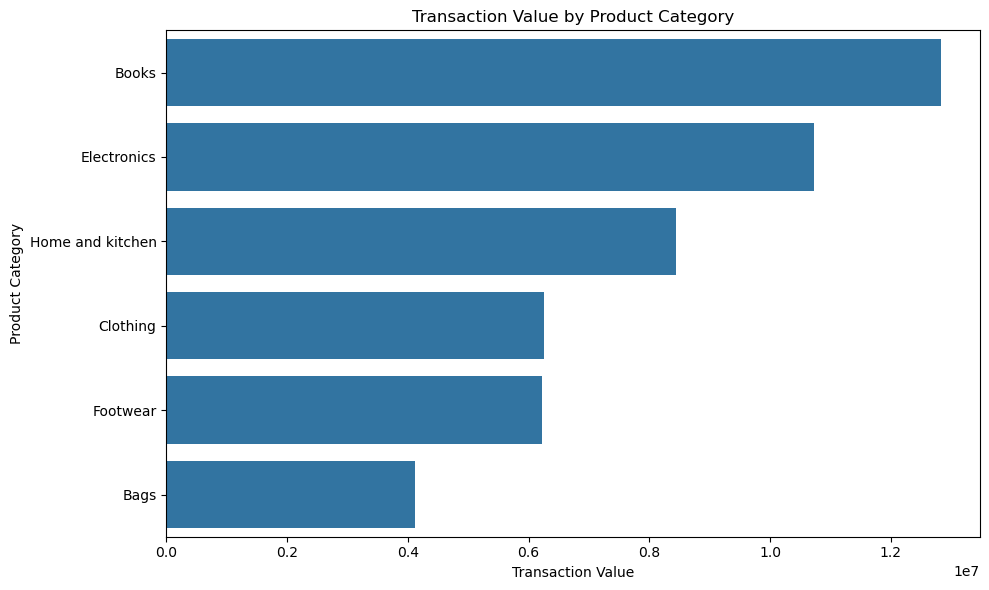

In [45]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_performance,
    x="Transaction_Value",
    y="prod_cat"
)

plt.title("Transaction Value by Product Category")
plt.xlabel("Transaction Value")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

In [46]:
subcategory_performance = (
    customer_final
    .groupby(
        ["prod_cat", "prod_subcat"]
    )
    .agg(
        Transaction_Value=("total_amt", "sum"),
        Quantity=("Qty", "sum"),
        Transactions=("transaction_id", "nunique"),
        Customers=("cust_id", "nunique")
    )
    .sort_values(
        "Transaction_Value",
        ascending=False
    )
    .reset_index()
)

display(subcategory_performance.head(15))

,prod_cat,prod_subcat,Transaction_Value,Quantity,Transactions,Customers
0,Electronics,Mobiles,"2,253,820.98",2591,947,876
1,Books,Fiction,"2,232,250.28",2573,940,867
2,Books,Children,"2,211,450.87",2487,934,861
3,Home and kitchen,Tools,"2,150,318.95",2594,971,885
4,Footwear,Kids,"2,145,126.56",2527,916,841
5,Books,Non-Fiction,"2,143,092.25",2462,916,832
6,Electronics,Audio and video,"2,140,057.92",2486,877,813
7,Electronics,Cameras,"2,133,390.35",2413,898,827
8,Bags,Mens,"2,124,756.98",2366,903,844
9,Electronics,Personal Appliances,"2,113,320.23",2433,888,823


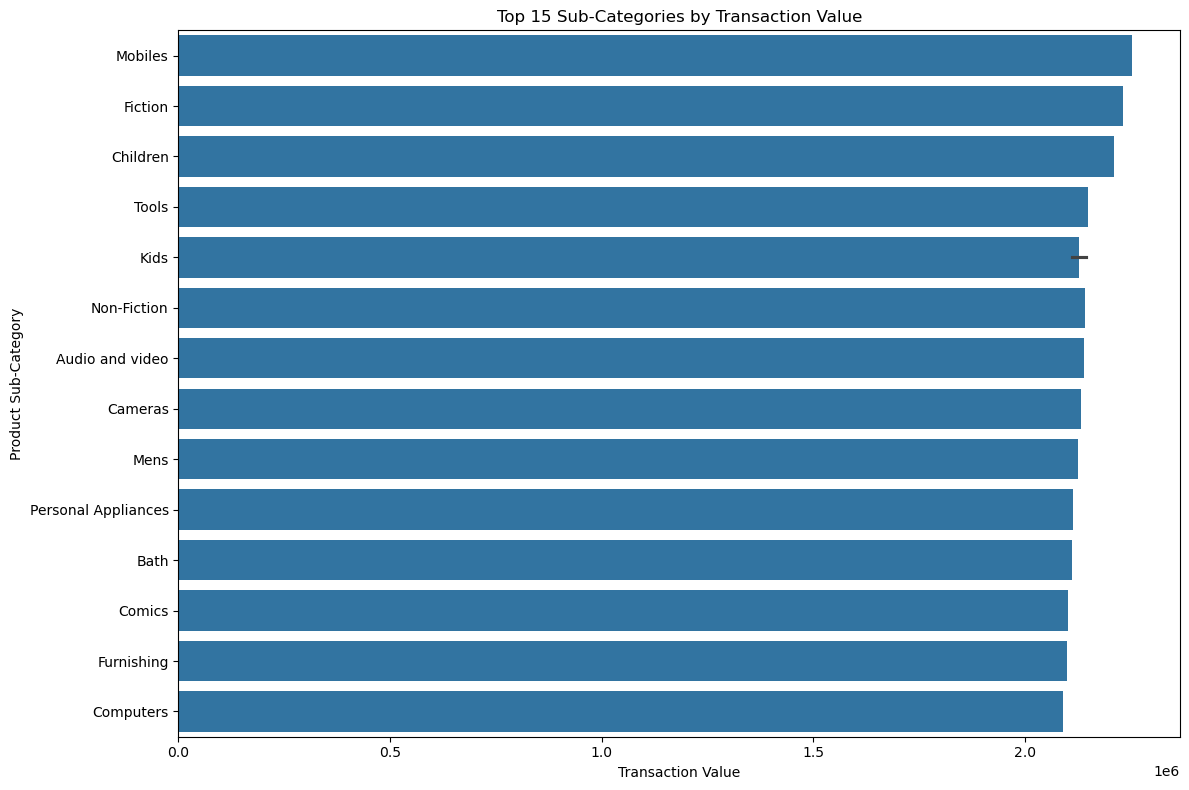

In [47]:
plt.figure(figsize=(12, 8))

top_15_subcategories = subcategory_performance.head(15)

sns.barplot(
    data=top_15_subcategories,
    x="Transaction_Value",
    y="prod_subcat"
)

plt.title("Top 15 Sub-Categories by Transaction Value")
plt.xlabel("Transaction Value")
plt.ylabel("Product Sub-Category")

plt.tight_layout()
plt.show()

# 14. Channel Performance Analysis

Store/channel performance is analyzed to identify which channels contribute most to transaction value, transaction volume, quantity sold, and customer reach.

In [48]:
channel_performance = (
    customer_final
    .groupby("Store_type")
    .agg(
        Transaction_Value=("total_amt", "sum"),
        Quantity=("Qty", "sum"),
        Transactions=("transaction_id", "nunique"),
        Customers=("cust_id", "nunique")
    )
    .sort_values(
        "Transaction_Value",
        ascending=False
    )
    .reset_index()
)

display(channel_performance)

,Store_type,Transaction_Value,Quantity,Transactions,Customers
0,e-Shop,"19,842,623.12",22790,8430,4366
1,Flagship store,"9,721,596.62",11142,4145,2941
2,MBR,"9,674,941.31",11195,4210,3000
3,TeleShop,"9,372,133.74",10993,4093,2912


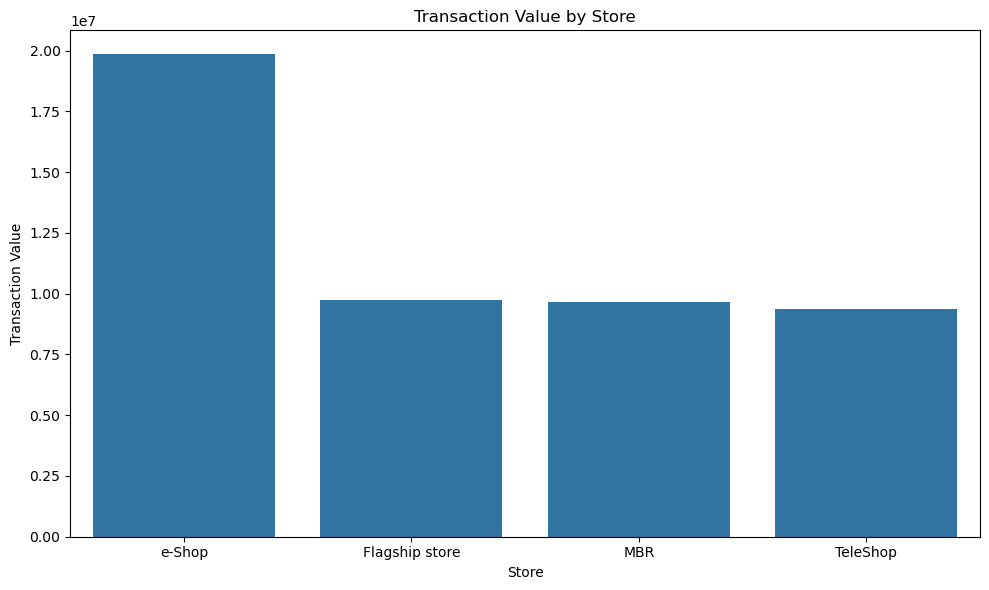

In [49]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=channel_performance,
    x="Store_type",
    y="Transaction_Value"
)

plt.title("Transaction Value by Store")
plt.xlabel("Store")
plt.ylabel("Transaction Value")

plt.tight_layout()
plt.show()

# 15. Customer Analysis
Customer-level analysis is performed to understand customer reach, purchasing behavior, transaction contribution, and customer value.
The analysis identifies high-value customers and examines how transaction value is distributed across the customer base.


### 15.1 Customer-level-Performance

In [55]:


customer_performance = (
    customer_final
    .groupby("cust_id")
    .agg(
        Transaction_Value=("total_amt", "sum"),
        Transactions=("transaction_id", "nunique"),
        Quantity=("Qty", "sum"),
        Categories=("prod_cat", "nunique")
    )
    .sort_values(
        "Transaction_Value",
        ascending=False
    )
    .reset_index()
)
display(customer_performance.head(10))


,cust_id,Transaction_Value,Transactions,Quantity,Categories
0,271834,"41,510.43",10,33,6
1,273140,"35,861.67",9,34,5
2,272354,"33,954.44",10,32,3
3,267419,"33,828.47",8,24,4
4,274948,"33,158.84",10,33,4
5,270908,"32,401.92",10,30,4
6,270535,"31,969.86",11,33,5
7,272799,"31,336.69",9,27,5
8,274227,"31,119.01",11,37,6
9,274747,"30,512.36",8,23,4


### 15.2 Customer Value Distribution
Customer transaction value is examined to understand the distribution of customer contribution and identify whether a relatively small group of customers contributes a significant share of transaction value.

In [53]:
customer_performance["Transaction_Value"].describe()

count    5,506.00
mean     8,828.79
std      5,872.44
min     -9,352.72
25%      4,326.07
50%      7,899.65
75%     12,423.24
max     41,510.43
Name: Transaction_Value, dtype: float64

### 15.3 Top Customers Visualization

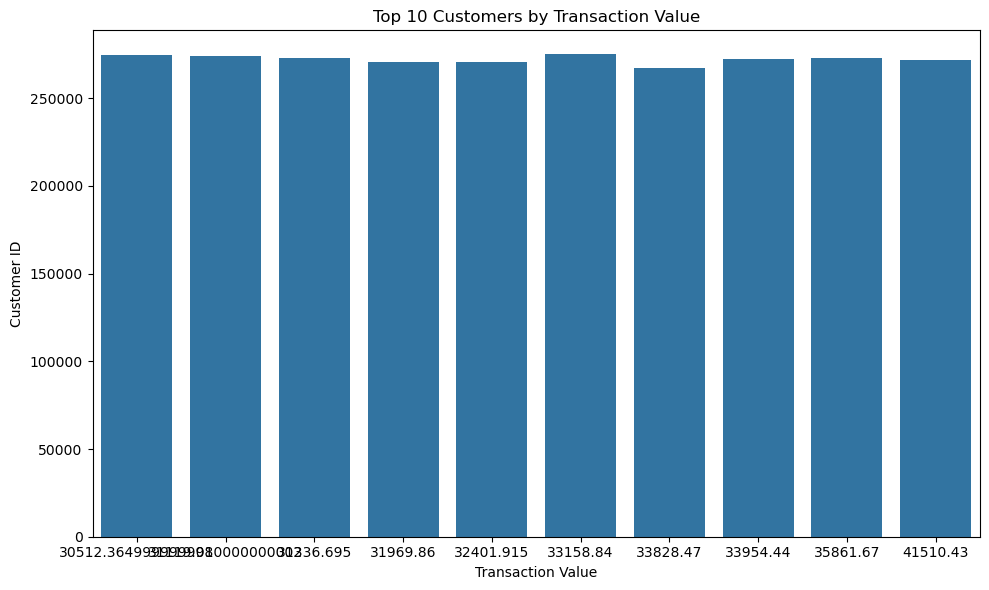

In [54]:
top_10_customers = customer_performance.head(10)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_10_customers,
    x="Transaction_Value",
    y="cust_id"
)
plt.title("Top 10 Customers by Transaction Value")
plt.xlabel("Transaction Value")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.show()


# 16. Customer Demographic Analysis
Customer demographic characteristics are analyzed to understand differences in transaction value, transaction volume, and customer participation across demographic groups.


### 16.1 Gender Analysis

In [56]:
gender_performance = (
    customer_final
    .groupby("Gender")
    .agg(
        Transaction_Value=("total_amt", "sum"),
        Transactions=("transaction_id", "nunique"),
        Customers=("cust_id", "nunique"),
        Quantity=("Qty", "sum")
    )
    .reset_index()
)
display(gender_performance)

,Gender,Transaction_Value,Transactions,Customers,Quantity
0,F,"23,637,172.13",10158,2678,27320
1,M,"24,953,496.75",10712,2826,28779


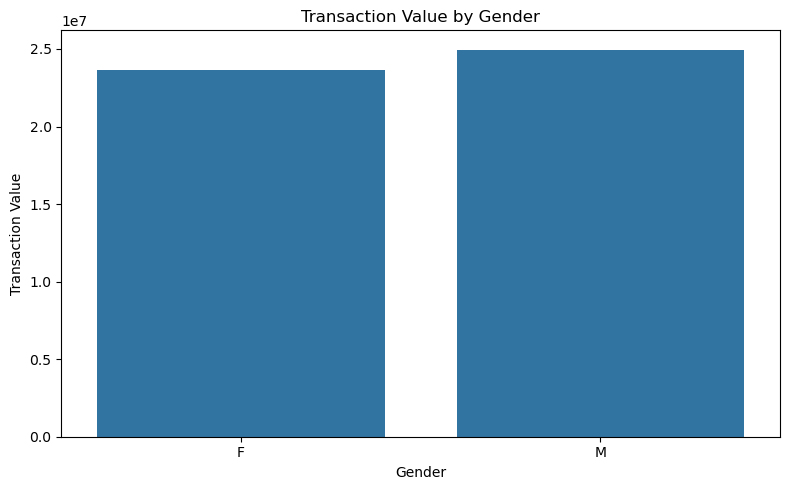

In [57]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=gender_performance,
    x="Gender",
    y="Transaction_Value"
)

plt.title("Transaction Value by Gender")
plt.xlabel("Gender")
plt.ylabel("Transaction Value")

plt.tight_layout()
plt.show()

### 16.2 City-Level Customer Analysis

Customer activity is analyzed across city codes to identify locations with higher customer participation and transaction value.

In [58]:
city_performance = (
    customer_final
    .groupby("city_code")
    .agg(
        Transaction_Value=("total_amt", "sum"),
        Customers=("cust_id", "nunique"),
        Transactions=("transaction_id", "nunique"),
        Quantity=("Qty", "sum")
    )
    .sort_values(
        "Transaction_Value",
        ascending=False
    )
    .reset_index()
)

display(city_performance.head(10))

,city_code,Transaction_Value,Customers,Transactions,Quantity
0,3.00,"5,170,318.21",576,2196,5941
1,4.00,"5,120,582.16",569,2195,5954
2,5.00,"4,938,770.98",570,2139,5736
3,7.00,"4,926,854.66",563,2126,5647
4,10.00,"4,863,301.69",546,2102,5569
5,2.00,"4,860,198.85",546,2046,5540
6,8.00,"4,860,178.96",551,2092,5568
7,1.00,"4,781,838.88",535,2066,5566
8,9.00,"4,703,292.17",532,1977,5374
9,6.00,"4,371,090.49",516,1931,5207


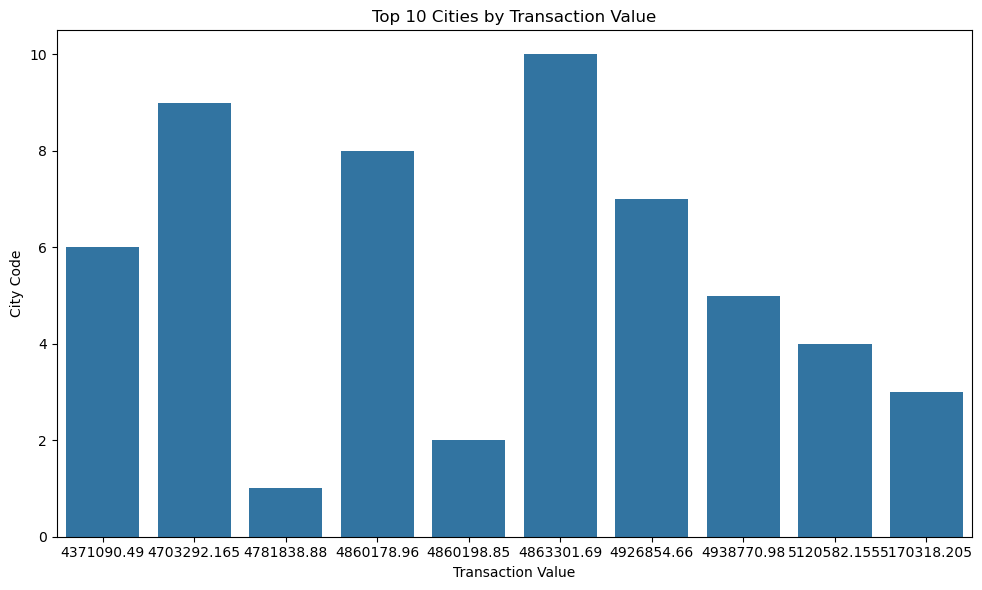

In [59]:
top_10_cities = city_performance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10_cities,
    x="Transaction_Value",
    y="city_code"
)

plt.title("Top 10 Cities by Transaction Value")
plt.xlabel("Transaction Value")
plt.ylabel("City Code")

plt.tight_layout()
plt.show()

# 17. Customer Age Analysis

Customer age is analyzed to identify differences in transaction activity and transaction value across customer age groups.

In [60]:
customer_final["Age_Group"] = pd.cut(
    customer_final["Age"],
    bins=[0, 18, 25, 35, 45, 55, 65, 100],
    labels=[
        "Under 18",
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "65+"
    ]
)

In [61]:
age_group_performance = (
    customer_final
    .groupby("Age_Group", observed=True)
    .agg(
        Transaction_Value=("total_amt", "sum"),
        Customers=("cust_id", "nunique"),
        Transactions=("transaction_id", "nunique"),
        Quantity=("Qty", "sum")
    )
    .reset_index()
)

display(age_group_performance)

,Age_Group,Transaction_Value,Customers,Transactions,Quantity
0,Under 18,"66,564.10",26,30,70
1,18-25,"12,625,511.21",1626,5440,14491
2,26-35,"21,089,034.39",2782,8994,24395
3,36-45,"14,830,185.11",1861,6417,17164


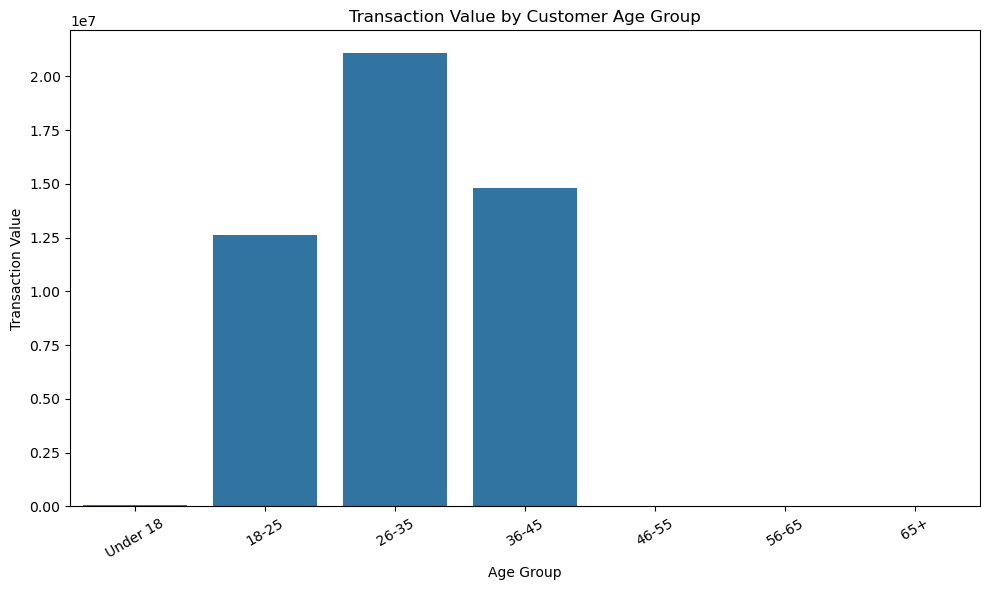

In [62]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=age_group_performance,
    x="Age_Group",
    y="Transaction_Value"
)

plt.title("Transaction Value by Customer Age Group")
plt.xlabel("Age Group")
plt.ylabel("Transaction Value")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

# 18. Returns Analysis

Negative-quantity transactions are analyzed as potential product returns or transaction reversals.

The objective is to understand the scale of return activity and identify the product categories and channels associated with higher return activity.

### 18.1 Sales vs Returns

In [63]:
return_summary = (
    customer_final
    .groupby("Transaction_Type")
    .agg(
        Transaction_Value=("total_amt", "sum"),
        Quantity=("Qty", "sum"),
        Transactions=("transaction_id", "nunique")
    )
    .reset_index()
)

display(return_summary)

,Transaction_Type,Transaction_Value,Quantity,Transactions
0,Return,"-5,842,590.26",-6581,2059
1,Sale,"54,453,885.07",62701,20876


### 18.2 Returns by Product Category

In [64]:
returns_by_category = (
    customer_final[
        customer_final["Transaction_Type"] == "Return"
    ]
    .groupby("prod_cat")
    .agg(
        Return_Value=("total_amt", "sum"),
        Return_Quantity=("Qty", "sum"),
        Return_Transactions=("transaction_id", "nunique")
    )
    .sort_values(
        "Return_Quantity"
    )
    .reset_index()
)

display(returns_by_category)

,prod_cat,Return_Value,Return_Quantity,Return_Transactions
0,Books,"-1,552,208.97",-1731,553
1,Electronics,"-1,112,770.36",-1240,393
2,Home and kitchen,"-1,048,347.76",-1232,375
3,Clothing,"-823,359.81",-894,270
4,Footwear,"-748,714.85",-844,272
5,Bags,"-557,188.52",-640,196


### 18.3 Returns by Channel

In [65]:
returns_by_channel = (
    customer_final[
        customer_final["Transaction_Type"] == "Return"
    ]
    .groupby("Store_type")
    .agg(
        Return_Value=("total_amt", "sum"),
        Return_Quantity=("Qty", "sum"),
        Return_Transactions=("transaction_id", "nunique")
    )
    .sort_values(
        "Return_Quantity"
    )
    .reset_index()
)

display(returns_by_channel)

,Store_type,Return_Value,Return_Quantity,Return_Transactions
0,e-Shop,"-2,342,986.75",-2645,835
1,MBR,"-1,233,595.48",-1386,430
2,Flagship store,"-1,185,023.00",-1318,407
3,TeleShop,"-1,080,985.03",-1232,387


# 19. Gross Sales, Returns and Net Transaction Value

Sales and return values are separated to distinguish gross sales activity from the impact of returns.

This provides a clearer view of the relationship between sales generated and value lost through returned transactions.

In [66]:
gross_sales = customer_final.loc[
    customer_final["Qty"] > 0,
    "total_amt"
].sum()

return_value = customer_final.loc[
    customer_final["Qty"] < 0,
    "total_amt"
].sum()

net_transaction_value = (
    gross_sales + return_value
)

print("Gross Sales Value:", gross_sales)
print("Return Value:", return_value)
print("Net Transaction Value:", net_transaction_value)

Gross Sales Value: 54453885.07000001
Return Value: -5842590.26
Net Transaction Value: 48611294.81000001


In [67]:
return_impact_percentage = (
    abs(return_value) / gross_sales
) * 100

print(
    "Return impact on gross sales:",
    round(return_impact_percentage, 2),
    "%"
)

Return impact on gross sales: 10.73 %


# 20. Product Category and Channel Analysis

Product category performance is compared across store/channel types to identify combinations of products and channels that generate higher transaction value.

In [68]:
category_channel = (
    customer_final
    .groupby(["Store_type", "prod_cat"])
    .agg(
        Transaction_Value=("total_amt", "sum"),
        Transactions=("transaction_id", "nunique"),
        Quantity=("Qty", "sum")
    )
    .reset_index()
)

display(
    category_channel.sort_values(
        "Transaction_Value",
        ascending=False
    ).head(20)
)

,Store_type,prod_cat,Transaction_Value,Transactions,Quantity
19,e-Shop,Books,"5,297,161.16",2213,5978
21,e-Shop,Electronics,"4,429,142.77",1836,5070
23,e-Shop,Home and kitchen,"3,327,977.12",1505,3956
22,e-Shop,Footwear,"2,643,215.25",1107,3038
13,TeleShop,Books,"2,545,714.47",1076,2903
20,e-Shop,Clothing,"2,527,193.56",1067,2901
7,MBR,Books,"2,496,039.19",1099,2929
1,Flagship store,Books,"2,493,677.81",1098,2869
3,Flagship store,Electronics,"2,215,136.04",906,2492
9,MBR,Electronics,"2,107,969.83",878,2422


In [69]:
category_channel_pivot = pd.pivot_table(
    customer_final,
    values="total_amt",
    index="prod_cat",
    columns="Store_type",
    aggfunc="sum"
)

display(category_channel_pivot)

Store_type,Flagship store,MBR,TeleShop,e-Shop
prod_cat,,,,
Bags,"870,548.83","848,678.68","789,181.06","1,617,933.26"
Books,"2,493,677.81","2,496,039.19","2,545,714.47","5,297,161.16"
Clothing,"1,194,423.23","1,287,686.33","1,241,834.36","2,527,193.56"
Electronics,"2,215,136.04","2,107,969.83","1,978,457.20","4,429,142.77"
Footwear,"1,234,806.56","1,112,163.72","1,235,719.29","2,643,215.25"
Home and kitchen,"1,713,004.15","1,822,403.57","1,581,227.38","3,327,977.12"


# 21. Monthly Sales Trend

Monthly transaction value is analyzed across the complete period to identify changes in sales performance over time.

In [70]:
monthly_trend = (
    customer_final
    .groupby(
        customer_final["tran_date"].dt.to_period("M")
    )["total_amt"]
    .sum()
    .reset_index()
)

monthly_trend["tran_date"] = (
    monthly_trend["tran_date"]
    .dt.to_timestamp()
)

monthly_trend.rename(
    columns={"total_amt": "Transaction_Value"},
    inplace=True
)

display(monthly_trend.head())

,tran_date,Transaction_Value
0,2011-01-01,"337,307.88"
1,2011-02-01,"1,087,283.53"
2,2011-03-01,"1,376,537.18"
3,2011-04-01,"1,379,838.92"
4,2011-05-01,"1,174,157.53"


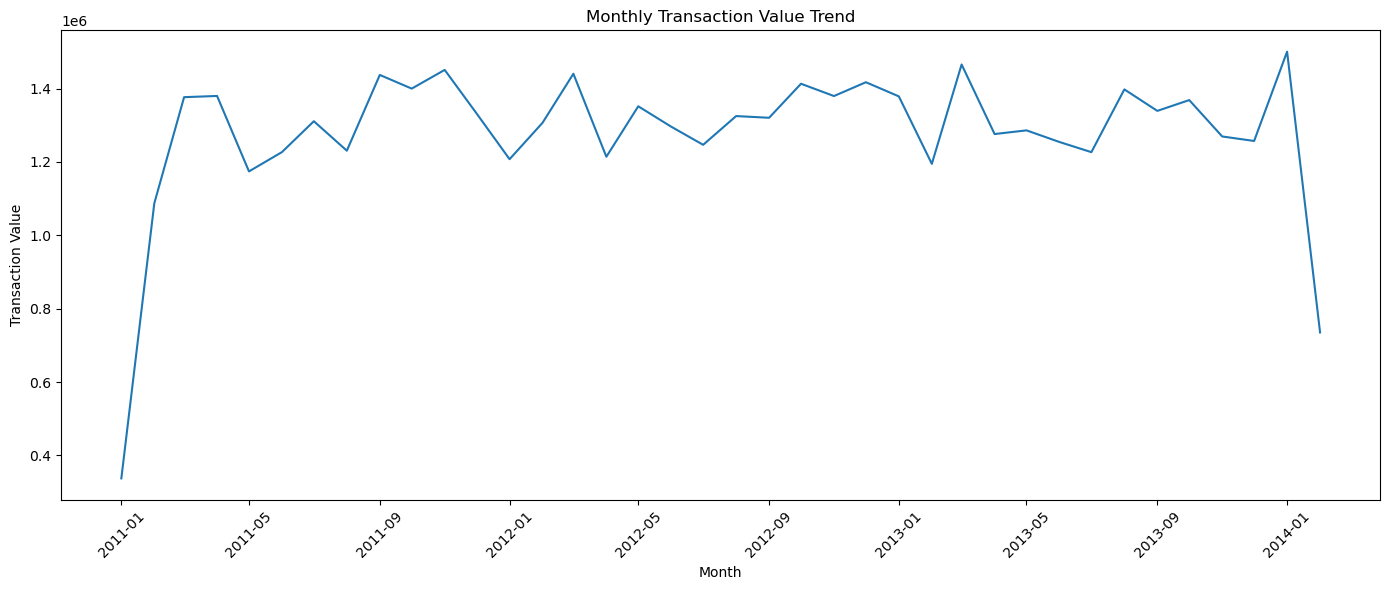

In [71]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_trend,
    x="tran_date",
    y="Transaction_Value"
)

plt.title("Monthly Transaction Value Trend")
plt.xlabel("Month")
plt.ylabel("Transaction Value")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 22. Key Business Findings

The analysis results are consolidated into key performance summaries to identify the strongest product categories, channels, customer groups, and locations.

In [72]:
print("Top Product Category:")
display(
    category_performance.head(3)
)

print("\nTop Store/Channel:")
display(
    channel_performance.head(3)
)

print("\nTop Cities:")
display(
    city_performance.head(5)
)

print("\nTop Customers:")
display(
    customer_performance.head(10)
)

Top Product Category:


,prod_cat,Transaction_Value,Quantity,Transactions,Customers
0,Books,"12,832,592.63",14679,5486,3480
1,Electronics,"10,730,705.83",12318,4486,3087
2,Home and kitchen,"8,444,612.21",9954,3733,2720



Top Store/Channel:


,Store_type,Transaction_Value,Quantity,Transactions,Customers
0,e-Shop,"19,842,623.12",22790,8430,4366
1,Flagship store,"9,721,596.62",11142,4145,2941
2,MBR,"9,674,941.31",11195,4210,3000



Top Cities:


,city_code,Transaction_Value,Customers,Transactions,Quantity
0,3.00,"5,170,318.21",576,2196,5941
1,4.00,"5,120,582.16",569,2195,5954
2,5.00,"4,938,770.98",570,2139,5736
3,7.00,"4,926,854.66",563,2126,5647
4,10.00,"4,863,301.69",546,2102,5569



Top Customers:


,cust_id,Transaction_Value,Transactions,Quantity,Categories
0,271834,"41,510.43",10,33,6
1,273140,"35,861.67",9,34,5
2,272354,"33,954.44",10,32,3
3,267419,"33,828.47",8,24,4
4,274948,"33,158.84",10,33,4
5,270908,"32,401.92",10,30,4
6,270535,"31,969.86",11,33,5
7,272799,"31,336.69",9,27,5
8,274227,"31,119.01",11,37,6
9,274747,"30,512.36",8,23,4


# 23. Executive KPI Summary

The following KPIs provide a consolidated executive-level view of the retail business performance.

In [73]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Net Transaction Value",
        "Gross Sales Value",
        "Return Value",
        "Unique Transactions",
        "Unique Customers",
        "Average Transaction Value",
        "Return Impact (%)"
    ],
    "Value": [
        net_transaction_value,
        gross_sales,
        return_value,
        total_transactions,
        unique_customers,
        average_transaction_value,
        round(return_impact_percentage, 2)
    ]
})

display(kpi_summary)

,KPI,Value
0,Net Transaction Value,"48,611,294.81"
1,Gross Sales Value,"54,453,885.07"
2,Return Value,"-5,842,590.26"
3,Unique Transactions,"20,878.00"
4,Unique Customers,"5,506.00"
5,Average Transaction Value,"2,109.87"
6,Return Impact (%),10.73


# 24. Business Insights

Based on the analysis, the following business insights are identified:

### Sales Performance
- Transaction value varies across the analysis period, indicating changes in sales performance over time.
- Annual and monthly trends provide visibility into periods of stronger and weaker transaction activity.

### Product Performance
- Product categories contribute differently to overall transaction value.
- The highest-performing categories and sub-categories represent important areas for product planning and inventory focus.

### Channel Performance
- Store/channel performance differs across channels.
- Higher-performing channels can be evaluated for strategies that may be replicated across lower-performing channels.

### Customer Performance
- Customer contribution to transaction value is not evenly distributed.
- A group of high-value customers contributes significantly to overall transaction activity and can be considered for customer retention initiatives.

### Customer Demographics
- Transaction activity varies across gender, age groups, and city codes.
- These differences can support more targeted customer segmentation and marketing decisions.

### Returns
- Negative-quantity transactions indicate return or reversal activity.
- Return patterns across product categories and channels can help identify areas requiring further investigation.

# 25. Business Recommendations

Based on the analytical findings, the following actions can be considered:

### 1. Strengthen High-Performing Product Categories
Prioritize inventory availability, promotional planning, and merchandising for consistently high-performing categories and sub-categories.

### 2. Improve Lower-Performing Product Areas
Investigate weaker categories to understand whether performance is affected by demand, pricing, product assortment, or channel availability.

### 3. Focus on High-Value Customers
Develop targeted retention and loyalty initiatives for customers contributing significantly to transaction value.

### 4. Optimize Channel Strategy
Study the characteristics of high-performing store/channel combinations and identify opportunities to improve weaker channels.

### 5. Investigate Return Patterns
Monitor categories and channels with relatively high return activity to identify potential product, quality, pricing, or customer-experience issues.

### 6. Use Customer Segmentation
Use customer demographics, transaction frequency, and transaction value to develop targeted marketing and customer engagement strategies.

### 7. Use Time-Based Sales Planning
Use monthly and annual transaction trends to support demand planning, inventory allocation, and promotional scheduling.

# 26. Conclusion

This project developed an end-to-end retail sales and customer analytics workflow by integrating customer, transaction, and product information.

The analysis covered data quality assessment, data cleaning, dataset integration, feature engineering, sales performance, product performance, channel performance, customer behavior, demographic analysis, and return activity.

The resulting analysis provides a consolidated view of retail performance and highlights business areas related to product planning, customer value, channel optimization, and return management.

The project demonstrates how raw transactional data can be transformed into structured business insights that support data-driven decision-making.

# 27. Final Dataset Validation

The final master dataset is checked to confirm its structure and readiness for further reporting and visualization.

In [74]:
print("Final Master Dataset Shape:")
print(customer_final.shape)

print("\nFinal Columns:")
print(customer_final.columns.tolist())

print("\nDuplicate Rows:")
print(customer_final.duplicated().sum())

print("\nMissing Values:")
display(customer_final.isna().sum())

Final Master Dataset Shape:
(23040, 22)

Final Columns:
['transaction_id', 'cust_id', 'tran_date', 'prod_subcat_code', 'prod_cat_code', 'Qty', 'Rate', 'Tax', 'total_amt', 'Store_type', 'DOB', 'Gender', 'city_code', 'prod_cat', 'prod_subcat', 'Year', 'Month', 'Month_Name', 'Quarter', 'Transaction_Type', 'Age', 'Age_Group']

Duplicate Rows:
0

Missing Values:


transaction_id      0
cust_id             0
tran_date           0
prod_subcat_code    0
prod_cat_code       0
Qty                 0
Rate                0
Tax                 0
total_amt           0
Store_type          0
DOB                 0
Gender              9
city_code           8
prod_cat            0
prod_subcat         0
Year                0
Month               0
Month_Name          0
Quarter             0
Transaction_Type    0
Age                 0
Age_Group           0
dtype: int64

In [75]:
display(customer_final.head())

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,DOB,Gender,city_code,prod_cat,prod_subcat,Year,Month,Month_Name,Quarter,Transaction_Type,Age,Age_Group
0,80712190438,270351,2014-02-28,1,1,-5,-772,405.30,"-4,265.30",e-Shop,1981-09-26,M,5.00,Clothing,Women,2014,2,February,1,Return,32.00,26-35
1,29258453508,270384,2014-02-27,5,3,-5,-1497,785.92,"-8,270.92",e-Shop,1973-05-11,F,8.00,Electronics,Computers,2014,2,February,1,Return,41.00,36-45
2,51750724947,273420,2014-02-24,6,5,-2,-791,166.11,"-1,748.11",TeleShop,1992-07-27,M,8.00,Books,DIY,2014,2,February,1,Return,22.00,18-25
3,93274880719,271509,2014-02-24,11,6,-3,-1363,429.35,"-4,518.35",e-Shop,1981-06-08,M,3.00,Home and kitchen,Bath,2014,2,February,1,Return,33.00,26-35
4,51750724947,273420,2014-02-23,6,5,-2,-791,166.11,"-1,748.11",TeleShop,1992-07-27,M,8.00,Books,DIY,2014,2,February,1,Return,22.00,18-25
